# Notebook 06 — Integração dos sentimentos à previsão da inadimplência

---

## 1. Objetivo do notebook

Este notebook integra as variáveis de sentimento textual à previsão da inadimplência total da carteira de crédito no Brasil.

A variável-alvo é `inad_total_tplus3`, que representa a inadimplência observada **três meses à frente** do mês de referência.

Os modelos estimados aqui são ARIMAX — ARIMA com variáveis exógenas — com a mesma ordem `(2, 1, 4)` fixada no Notebook 02. Isso permite isolar o efeito do sentimento textual em relação ao modelo-base.

A avaliação preditiva é feita por **walk-forward**, com reestimação temporal mês a mês, evitando uma previsão única de múltiplos passos para todo o teste.

### Posição no projeto

| Notebook | Objetivo |
|----------|----------|
| 01 | Coleta e organização das séries quantitativas |
| 02 | Modelos-base sem sentimento (benchmark) |
| 03 | Coleta e tratamento dos textos do Banco Central |
| 04 | Geração dos scores de sentimento |
| 05 | Seleção diagnóstica por correlação |
| **06** | **Integração dos sentimentos à previsão e Comparação final entre modelos com e sem sentimento **  |

### Sentimentos selecionados no Notebook 05

| Ranking | Tipo | Modelo | Lag | Pearson r |
|---------|------|--------|-----|-----------|
| 1 | Copom | BERT Multilingual | 6 | 0.5483 |
| 2 | Copom | Mistral | 6 | -0.4019 |
| 3 | Estatísticas | FinBERT-PT-BR | 6 | 0.2809 |
| 4 (complementar) | Estatísticas | NLTK/VADER | 4 | -0.2614 |

### Benchmark do Notebook 02

| Métrica | Valor |
|---------|-------|
| MAE | 0.143668 |
| RMSE | 0.184052 |
| R² | 0.687889 |
| Bias obs - prev | -0.003919 |
| Slope pred~obs | 0.734977 |
| Intercept | 0.912617 |


---

## 2. Importação das bibliotecas

In [1]:
# Instalação de dependências (descomente se necessário)
# !pip install statsmodels scikit-learn pandas numpy matplotlib

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("Bibliotecas importadas com sucesso.")

Bibliotecas importadas com sucesso.


---

## 3. Definição das configurações centrais

Todos os parâmetros principais do notebook são definidos aqui para facilitar a manutenção e garantir alinhamento com o Notebook 02.

In [2]:
# ── Configurações centrais ──────────────────────────────────────────────────

# Arquivo de entrada exportado pelo Notebook 05
ARQUIVO_BASE = "base_completa.csv"

# Variável-alvo: inadimplência observada em t+3
VARIAVEL_ALVO = "inad_total_tplus3"

# Horizonte de previsão (em meses)
H = 3

# Data de corte para split treino/teste (coluna data_alvo)
SPLIT_DATE = "2024-01-01"

# Ordem ARIMA fixada — igual ao Notebook 02 (isola efeito do sentimento)
ORDEM_ARIMA = (2, 1, 4)

# Cor principal para os gráficos
COLOR = "#0e5764"

# Mínimo de observações para estimar o modelo
MIN_OBS_TREINO = 30
MIN_OBS_TESTE = 5

# ── Métricas do benchmark (Notebook 02) ────────────────────────────────────
RMSE_BASE_ARIMA_BIAS = 0.184052
MAE_BASE_ARIMA_BIAS  = 0.143668
R2_BASE_ARIMA_BIAS   = 0.687889

print("=== Configurações centrais ===")
print(f"Arquivo de entrada : {ARQUIVO_BASE}")
print(f"Variável-alvo      : {VARIAVEL_ALVO}")
print(f"Horizonte          : h = {H} meses")
print(f"Data de corte      : {SPLIT_DATE}")
print(f"Ordem ARIMA        : {ORDEM_ARIMA}")
print(f"RMSE benchmark     : {RMSE_BASE_ARIMA_BIAS}")

=== Configurações centrais ===
Arquivo de entrada : base_completa.csv
Variável-alvo      : inad_total_tplus3
Horizonte          : h = 3 meses
Data de corte      : 2024-01-01
Ordem ARIMA        : (2, 1, 4)
RMSE benchmark     : 0.184052


---

## 4. Carregamento da base exportada pelo Notebook 05

In [3]:
# Carregamento principal
base = pd.read_csv(ARQUIVO_BASE)

# Padronização dos nomes de colunas
base.columns = [c.strip().lower() for c in base.columns]

# Remover coluna de índice extra, se existir
base = base.drop(columns=["unnamed: 0", "Unnamed: 0"], errors="ignore")

print(f"Base carregada: {base.shape[0]} linhas x {base.shape[1]} colunas")
print(f"Período: {base['data'].min()} a {base['data'].max()}")

Base carregada: 75 linhas x 82 colunas
Período: 2019-07-01 a 2025-09-01


---

## 5. Verificação inicial da base

In [4]:
# Listagem completa de colunas
print("=== Colunas disponíveis na base ===")
for i, col in enumerate(base.columns):
    print(f"  [{i:02d}] {col}")

=== Colunas disponíveis na base ===
  [00] data
  [01] data_alvo
  [02] inad_total_tplus3
  [03] inad_total
  [04] inad_total_l1
  [05] inad_total_l2
  [06] inad_total_l3
  [07] inad_total_l4
  [08] inad_total_l5
  [09] inad_total_l6
  [10] copom_score_nltk_l1
  [11] copom_score_nltk_l2
  [12] copom_score_nltk_l3
  [13] copom_score_nltk_l4
  [14] copom_score_nltk_l5
  [15] copom_score_nltk_l6
  [16] copom_score_textblob_l1
  [17] copom_score_textblob_l2
  [18] copom_score_textblob_l3
  [19] copom_score_textblob_l4
  [20] copom_score_textblob_l5
  [21] copom_score_textblob_l6
  [22] copom_score_bert_l1
  [23] copom_score_bert_l2
  [24] copom_score_bert_l3
  [25] copom_score_bert_l4
  [26] copom_score_bert_l5
  [27] copom_score_bert_l6
  [28] copom_score_finbert_l1
  [29] copom_score_finbert_l2
  [30] copom_score_finbert_l3
  [31] copom_score_finbert_l4
  [32] copom_score_finbert_l5
  [33] copom_score_finbert_l6
  [34] copom_score_mistral_l1
  [35] copom_score_mistral_l2
  [36] copom_sco

In [5]:
# Verificação de tipos e valores ausentes
print("=== Tipos de dados ===")
print(base.dtypes)
print()
print("=== Valores ausentes por coluna (apenas colunas com NaN) ===")
nulos = base.isna().sum()
print(nulos[nulos > 0])

=== Tipos de dados ===
data                               str
data_alvo                          str
inad_total_tplus3              float64
inad_total                     float64
inad_total_l1                  float64
                                ...   
estatisticas_score_media_l2    float64
estatisticas_score_media_l3    float64
estatisticas_score_media_l4    float64
estatisticas_score_media_l5    float64
estatisticas_score_media_l6    float64
Length: 82, dtype: object

=== Valores ausentes por coluna (apenas colunas com NaN) ===
Series([], dtype: int64)


In [6]:
# Prévia da base
display(base.head(5))

,data,data_alvo,inad_total_tplus3,inad_total,inad_total_l1,inad_total_l2,inad_total_l3,inad_total_l4,inad_total_l5,inad_total_l6,...,estatisticas_score_mistral_l3,estatisticas_score_mistral_l4,estatisticas_score_mistral_l5,estatisticas_score_mistral_l6,estatisticas_score_media_l1,estatisticas_score_media_l2,estatisticas_score_media_l3,estatisticas_score_media_l4,estatisticas_score_media_l5,estatisticas_score_media_l6
0,2019-07-01,2019-10-01,3.03,3.06,2.95,3.05,3.02,2.99,2.91,2.95,...,-0.5,-0.3,-0.6,-0.3,-0.399907,-0.537258,-0.497275,-0.466614,-0.550717,-0.421406
1,2019-08-01,2019-11-01,3.00,3.04,3.06,2.95,3.05,3.02,2.99,2.91,...,-0.5,-0.5,-0.3,-0.6,-0.359629,-0.399907,-0.537258,-0.497275,-0.466614,-0.550717
2,2019-09-01,2019-12-01,2.94,3.06,3.04,3.06,2.95,3.05,3.02,2.99,...,-0.2,-0.5,-0.5,-0.3,-0.489411,-0.359629,-0.399907,-0.537258,-0.497275,-0.466614
3,2019-10-01,2020-01-01,3.00,3.03,3.06,3.04,3.06,2.95,3.05,3.02,...,-0.1,-0.2,-0.5,-0.5,-0.341160,-0.489411,-0.359629,-0.399907,-0.537258,-0.497275
4,2019-11-01,2020-02-01,3.04,3.00,3.03,3.06,3.04,3.06,2.95,3.05,...,-0.2,-0.1,-0.2,-0.5,-0.385238,-0.341160,-0.489411,-0.359629,-0.399907,-0.537258


Embora a base contenha os lags explícitos da inadimplência (`inad_total_l1` a `inad_total_l6`) para fins de rastreabilidade e comparação com modelos tabulares, no ARIMAX esses lags não são inseridos manualmente como variáveis exógenas. A dependência temporal da inadimplência é capturada pela própria estrutura ARIMA, enquanto as variáveis de sentimento entram como variáveis externas.

---

## 6. Tratamento das datas e ordenação temporal

In [7]:
# Converter colunas de data para datetime
base["data"] = pd.to_datetime(base["data"], errors="coerce")
base["data_alvo"] = pd.to_datetime(base["data_alvo"], errors="coerce")

# Ordenar por data
base = base.sort_values("data").reset_index(drop=True)

print("=== Verificação das datas ===")
print(f"data      : {base['data'].min().date()} a {base['data'].max().date()}")
print(f"data_alvo : {base['data_alvo'].min().date()} a {base['data_alvo'].max().date()}")
print(f"Linhas com data_alvo nula: {base['data_alvo'].isna().sum()}")
print(f"Linhas com data nula     : {base['data'].isna().sum()}")

=== Verificação das datas ===
data      : 2019-07-01 a 2025-09-01
data_alvo : 2019-10-01 a 2025-12-01
Linhas com data_alvo nula: 0
Linhas com data nula     : 0


---

## 7. Validação das colunas obrigatórias

In [8]:
# Colunas que devem existir obrigatoriamente
colunas_obrigatorias = ["data", "data_alvo", VARIAVEL_ALVO]

colunas_ausentes = [c for c in colunas_obrigatorias if c not in base.columns]

if colunas_ausentes:
    raise ValueError(
        f"As seguintes colunas obrigatórias não foram encontradas na base: {colunas_ausentes}\n"
        "Verifique se o Notebook 05 exportou corretamente a base_completa.csv."
    )
else:
    print("Todas as colunas obrigatórias estão presentes.")

# Verificar se a variável-alvo tem valores
n_alvo_valido = base[VARIAVEL_ALVO].notna().sum()
print(f"Observações válidas em {VARIAVEL_ALVO}: {n_alvo_valido} de {len(base)}")

Todas as colunas obrigatórias estão presentes.
Observações válidas em inad_total_tplus3: 75 de 75


---

## 8. Identificação das variáveis de sentimento disponíveis

Esta etapa lista todos os lags L1–L6 disponíveis para cada modelo de sentimento selecionado pelo Notebook 05.

> **Nota:** Os lags identificados no Notebook 05 por correlação foram utilizados apenas como **evidência diagnóstica** (triagem de modelos). No Notebook 06, a escolha final dos lags é feita por **desempenho preditivo**, com base no RMSE em validação temporal. Assim, evita-se transformar uma correlação exploratória em critério final de modelagem.

In [9]:
# ── Identificação automática das colunas de sentimento defasado ─────────────
# As colunas de sentimento seguem o padrão: {tipo_relatorio}_{score_modelo}_L{lag}
# Exemplo: copom_score_bert_L6 | estatisticas_score_finbert_L6

# Padrões esperados com base no Notebook 05
PREFIXOS_SENTIMENTO = ["copom_", "estatisticas_"]
SUFIXOS_SCORE = ["score_bert", "score_mistral", "score_finbert", "score_nltk",
                 "score_textblob", "score_media"]

# Listar todas as colunas que contêm sentimento defasado
colunas_sentimento = [
    c for c in base.columns
    if any(c.startswith(pref) for pref in PREFIXOS_SENTIMENTO)
    and any(score in c for score in SUFIXOS_SCORE)
    and "_l" in c  # presença do lag
]

print(f"Colunas de sentimento defasado encontradas: {len(colunas_sentimento)}")
print()
for c in sorted(colunas_sentimento):
    n_validos = base[c].notna().sum()
    print(f"  {c:50s}  — {n_validos} obs. válidas")

Colunas de sentimento defasado encontradas: 72

  copom_score_bert_l1                                 — 75 obs. válidas
  copom_score_bert_l2                                 — 75 obs. válidas
  copom_score_bert_l3                                 — 75 obs. válidas
  copom_score_bert_l4                                 — 75 obs. válidas
  copom_score_bert_l5                                 — 75 obs. válidas
  copom_score_bert_l6                                 — 75 obs. válidas
  copom_score_finbert_l1                              — 75 obs. válidas
  copom_score_finbert_l2                              — 75 obs. válidas
  copom_score_finbert_l3                              — 75 obs. válidas
  copom_score_finbert_l4                              — 75 obs. válidas
  copom_score_finbert_l5                              — 75 obs. válidas
  copom_score_finbert_l6                              — 75 obs. válidas
  copom_score_media_l1                                — 75 obs. válidas
  copom_score_me

In [10]:
# ── Busca automática de colunas por tipo, modelo e lag ──────────────────────
def buscar_coluna(base, tipo, modelo, lag):
    """Localiza a coluna de sentimento com base no tipo de relatório, modelo e lag."""
    candidatas = [
        c for c in base.columns
        if tipo.lower() in c.lower()
        and modelo.lower() in c.lower()
        and f"_l{lag}" in c.lower()
    ]
    return candidatas[0] if candidatas else None

# ── Modelos selecionados pelo Notebook 05 ──────────────
MODELOS_SENTIMENTO = {
    "bert_copom"    : {"tipo": "copom",        "modelo": "bert",    "label": "BERT Copom"},
    "mistral_copom" : {"tipo": "copom",        "modelo": "mistral", "label": "Mistral Copom"},
    "finbert_estat" : {"tipo": "estatisticas", "modelo": "finbert", "label": "FinBERT Estat."},
    "nltk_estat"    : {"tipo": "estatisticas", "modelo": "nltk",    "label": "NLTK/VADER Estat."},
}

LAGS_DISPONIVEIS = list(range(1, 7))  # L1 a L6

# ── Mapear todos os lags L1–L6 para cada modelo ─────────────────────────────
mapa_lags = {}

for chave, config in MODELOS_SENTIMENTO.items():
    mapa_lags[chave] = {}
    for lag in LAGS_DISPONIVEIS:
        coluna = buscar_coluna(base, config["tipo"], config["modelo"], lag)
        mapa_lags[chave][lag] = coluna

#Tabela de disponibilidade
tabela_disponibilidade = pd.DataFrame([
    {
        "Modelo": MODELOS_SENTIMENTO[chave]["label"],
        **{f"L{lag}": (mapa_lags[chave][lag] if mapa_lags[chave][lag] else "ausente")
           for lag in LAGS_DISPONIVEIS}
    }
    for chave in mapa_lags
])

print("=== Disponibilidade de lags L1–L6 por modelo de sentimento ===")
display(tabela_disponibilidade)
print()

# Avisos para lags ausentes
for chave in mapa_lags:
    label = MODELOS_SENTIMENTO[chave]["label"]
    lags_ausentes = [lag for lag in LAGS_DISPONIVEIS if mapa_lags[chave][lag] is None]
    if lags_ausentes:
        print(f"'{label}': lags ausentes → {['L'+str(l) for l in lags_ausentes]}")
        print("    Verifique os nomes exatos na célula de listagem de colunas e ajuste buscar_coluna().")
    else:
        print(f"'{label}': todos os lags L1–L6 encontrados.")

=== Disponibilidade de lags L1–L6 por modelo de sentimento ===


,Modelo,L1,L2,L3,L4,L5,L6
0,BERT Copom,copom_score_bert_l1,copom_score_bert_l2,copom_score_bert_l3,copom_score_bert_l4,copom_score_bert_l5,copom_score_bert_l6
1,Mistral Copom,copom_score_mistral_l1,copom_score_mistral_l2,copom_score_mistral_l3,copom_score_mistral_l4,copom_score_mistral_l5,copom_score_mistral_l6
2,FinBERT Estat.,estatisticas_score_finbert_l1,estatisticas_score_finbert_l2,estatisticas_score_finbert_l3,estatisticas_score_finbert_l4,estatisticas_score_finbert_l5,estatisticas_score_finbert_l6
3,NLTK/VADER Estat.,estatisticas_score_nltk_l1,estatisticas_score_nltk_l2,estatisticas_score_nltk_l3,estatisticas_score_nltk_l4,estatisticas_score_nltk_l5,estatisticas_score_nltk_l6



'BERT Copom': todos os lags L1–L6 encontrados.
'Mistral Copom': todos os lags L1–L6 encontrados.
'FinBERT Estat.': todos os lags L1–L6 encontrados.
'NLTK/VADER Estat.': todos os lags L1–L6 encontrados.


---

## 9. Definição das janelas de lags

Para cada modelo de sentimento, são testadas **janelas acumuladas** de L1 a L6:

| Janela | Variáveis exógenas incluídas |
|--------|------------------------------|
| L1 | L1 |
| L2 | L1, L2 |
| L3 | L1, L2, L3 |
| L4 | L1, L2, L3, L4 |
| L5 | L1, L2, L3, L4, L5 |
| L6 | L1, L2, L3, L4, L5, L6 |


In [11]:
# ── Construção das janelas acumuladas de lags ────────────────────────────────
# Para cada modelo × janela W: exog = [L1, L2, ..., LW] (apenas colunas encontradas)

modelos_candidatos = []

for chave, config in MODELOS_SENTIMENTO.items():
    for janela in LAGS_DISPONIVEIS:
        colunas_janela = [
            mapa_lags[chave][lag]
            for lag in range(1, janela + 1)
            if mapa_lags[chave][lag] is not None
        ]
        lags_incluidos  = [lag for lag in range(1, janela + 1) if mapa_lags[chave][lag] is not None]
        lags_faltando   = [lag for lag in range(1, janela + 1) if mapa_lags[chave][lag] is None]

        if not colunas_janela:
            continue

        if lags_faltando:
            print(f"⚠️  {chave}_janela_L{janela}: lags faltando no interior da janela → "
                  f"{['L'+str(l) for l in lags_faltando]}")

        modelos_candidatos.append({
            "nome_modelo"   : chave,
            "label_modelo"  : config["label"],
            "nome_janela"   : f"{chave}_janela_L{janela}",
            "janela"        : janela,
            "colunas_exog"  : colunas_janela,
            "lags_incluidos": lags_incluidos,
        })

print(f"Total de combinações modelo × janela para testar na Etapa A: {len(modelos_candidatos)}")
print()
for m in modelos_candidatos:
    lags_str = ", ".join([f"L{l}" for l in m["lags_incluidos"]])
    print(f"  {m['nome_janela']:38s}  lags: [{lags_str}]")

Total de combinações modelo × janela para testar na Etapa A: 24

  bert_copom_janela_L1                    lags: [L1]
  bert_copom_janela_L2                    lags: [L1, L2]
  bert_copom_janela_L3                    lags: [L1, L2, L3]
  bert_copom_janela_L4                    lags: [L1, L2, L3, L4]
  bert_copom_janela_L5                    lags: [L1, L2, L3, L4, L5]
  bert_copom_janela_L6                    lags: [L1, L2, L3, L4, L5, L6]
  mistral_copom_janela_L1                 lags: [L1]
  mistral_copom_janela_L2                 lags: [L1, L2]
  mistral_copom_janela_L3                 lags: [L1, L2, L3]
  mistral_copom_janela_L4                 lags: [L1, L2, L3, L4]
  mistral_copom_janela_L5                 lags: [L1, L2, L3, L4, L5]
  mistral_copom_janela_L6                 lags: [L1, L2, L3, L4, L5, L6]
  finbert_estat_janela_L1                 lags: [L1]
  finbert_estat_janela_L2                 lags: [L1, L2]
  finbert_estat_janela_L3                 lags: [L1, L2, L3]
  finber

---

## 10. Separação treino e teste pela coluna `data_alvo`

O split é feito pela coluna `data_alvo`, que representa o mês sendo previsto (t+3). Isso é idêntico ao Notebook 02 e evita vazamento de informação.

- **Treino:** `data_alvo < 2024-01-01`
- **Teste:** `data_alvo >= 2024-01-01`

In [12]:
split_dt = pd.Timestamp(SPLIT_DATE)

# Remover linhas sem a variável-alvo ou sem data_alvo
base_fit = base.dropna(subset=[VARIAVEL_ALVO, "data_alvo"]).copy()

# ── Split temporal oficial ───────────────────────────────────────────────────
base_treino = base_fit[base_fit["data_alvo"] <  split_dt].copy().reset_index(drop=True)
base_teste  = base_fit[base_fit["data_alvo"] >= split_dt].copy().reset_index(drop=True)

# ── Validação temporal interna (para seleção de lags — Etapa A) ──────────────
# Últimos 12 meses do treino = validação interna
# O teste oficial NÃO é consultado nesta etapa
data_max_treino        = base_treino["data_alvo"].max()
data_inicio_validacao  = data_max_treino - pd.DateOffset(months=11)

base_treino_selecao    = base_treino[base_treino["data_alvo"] <  data_inicio_validacao].copy().reset_index(drop=True)
base_validacao_selecao = base_treino[base_treino["data_alvo"] >= data_inicio_validacao].copy().reset_index(drop=True)

print("=== Split oficial (por data_alvo) ===")
print(f"Treino oficial  : {base_treino['data_alvo'].min().date()} → "
      f"{base_treino['data_alvo'].max().date()}  | {len(base_treino)} obs.")
print(f"Teste oficial   : {base_teste['data_alvo'].min().date()} → "
      f"{base_teste['data_alvo'].max().date()}  | {len(base_teste)} obs.")
print()
print("=== Validação temporal interna (dentro do treino) ===")
print(f"Treino seleção  : {base_treino_selecao['data_alvo'].min().date()} → "
      f"{base_treino_selecao['data_alvo'].max().date()}  | {len(base_treino_selecao)} obs.")
print(f"Validação interna: {base_validacao_selecao['data_alvo'].min().date()} → "
      f"{base_validacao_selecao['data_alvo'].max().date()}  | {len(base_validacao_selecao)} obs.")
print()
print("O conjunto de teste oficial NÃO será usado para seleção de lags.")

overlap = set(base_treino["data_alvo"]) & set(base_teste["data_alvo"])
print(f"Sobreposição treino/teste: {overlap or 'nenhuma ✅'}")

=== Split oficial (por data_alvo) ===
Treino oficial  : 2019-10-01 → 2023-12-01  | 51 obs.
Teste oficial   : 2024-01-01 → 2025-12-01  | 24 obs.

=== Validação temporal interna (dentro do treino) ===
Treino seleção  : 2019-10-01 → 2022-12-01  | 39 obs.
Validação interna: 2023-01-01 → 2023-12-01  | 12 obs.

O conjunto de teste oficial NÃO será usado para seleção de lags.
Sobreposição treino/teste: nenhuma ✅


---

## 11. Funções auxiliares

### 11.1 Função de cálculo das métricas

In [13]:
def calcular_metricas(y_obs, y_prev):
    """
    Calcula as métricas de avaliação preditiva.

    Parâmetros
    ----------
    y_obs  : array-like — valores observados
    y_prev : array-like — valores previstos

    Retorna
    -------
    dict com: MAE, RMSE, R2, Bias_obs_menos_prev, Slope_pred_obs, Intercepto

    Nota sobre slope e intercept:
    A regressão é predito ~ observado, ou seja:
        X = y_obs  (variável independente)
        y = y_prev (variável dependente)
    Isso verifica se as previsões acompanham linearmente os valores observados.
    """
    y_obs  = np.array(y_obs,  dtype=float)
    y_prev = np.array(y_prev, dtype=float)

    # Remover pares com NaN
    mascara = ~(np.isnan(y_obs) | np.isnan(y_prev))
    y_obs  = y_obs[mascara]
    y_prev = y_prev[mascara]

    mae  = mean_absolute_error(y_obs, y_prev)
    rmse = np.sqrt(mean_squared_error(y_obs, y_prev))
    r2   = r2_score(y_obs, y_prev)

    # Bias: observado - previsto (média)
    bias = np.mean(y_obs - y_prev)

    # Regressão: predito ~ observado
    X_reg = y_obs.reshape(-1, 1)
    reg   = LinearRegression().fit(X_reg, y_prev)
    slope     = float(reg.coef_[0])
    intercepto = float(reg.intercept_)

    return {
        "MAE"                : round(mae,        6),
        "RMSE"               : round(rmse,       6),
        "R2"                 : round(r2,         6),
        "Bias_obs_menos_prev": round(bias,       6),
        "Slope_pred_obs"     : round(slope,      6),
        "Intercepto"         : round(intercepto, 6),
    }

print("Função calcular_metricas definida.")

Função calcular_metricas definida.


### 11.2 Função de ajuste do ARIMAX

In [14]:
def ajustar_arimax(endog, exog=None, order=(2, 1, 4)):
    """
    Ajusta ARIMA/ARIMAX usando SARIMAX.

    Se exog for None, o modelo funciona como ARIMA.
    Se exog for informado, o modelo funciona como ARIMAX.
    """
    modelo = SARIMAX(
        endog=endog,
        exog=exog,
        order=order,
        enforce_stationarity=True,
        enforce_invertibility=True
    )

    ajuste = modelo.fit(disp=False)
    return ajuste

### 11.3 Funções de previsão walk-forward e correção de bias

A previsão do teste e da validação interna será feita com a mesma lógica utilizada no ARIMA do Notebook 02: **walk-forward com horizonte h = 3**.

Isso significa que, para cada `data_alvo` avaliada, o modelo:

1. treina com a amostra histórica disponível até a origem da previsão;
2. prevê `h` passos à frente;
3. guarda apenas o `h`-ésimo passo, correspondente à `data_alvo`;
4. estima o bias exclusivamente no treino, também por walk-forward;
5. aplica esse bias às previsões do período avaliado.

Assim, o Notebook 06 mantém a comparabilidade com o Notebook 02. A diferença é que aqui o ARIMA é estimado como ARIMAX quando há variáveis exógenas de sentimento.


In [15]:
def preparar_series_arimax(base_modelo, variavel_alvo, variaveis_exogenas):
    """
    Prepara a série-alvo e, quando houver, as variáveis exógenas.

    A coluna data_alvo é usada como índice temporal, pois representa o mês
    efetivamente previsto em h=3.
    """
    variaveis_exogenas = list(variaveis_exogenas)

    colunas_necessarias = ["data_alvo", variavel_alvo] + variaveis_exogenas
    colunas_ausentes = [c for c in colunas_necessarias if c not in base_modelo.columns]

    if colunas_ausentes:
        raise ValueError(f"Colunas ausentes: {colunas_ausentes}")

    base_aux = (
        base_modelo[colunas_necessarias]
        .copy()
        .assign(data_alvo=lambda df: pd.to_datetime(df["data_alvo"]))
        .dropna()
        .drop_duplicates(subset="data_alvo", keep="last")
        .sort_values("data_alvo")
        .set_index("data_alvo")
    )

    y = base_aux[variavel_alvo].astype(float)

    if variaveis_exogenas:
        X = base_aux[variaveis_exogenas].astype(float)
    else:
        X = None

    return y, X


def walk_forward_arimax_h(endog, exog=None, train_size=30,
                          order=(2, 1, 4), h=3, padronizar=True):
    """
    Executa walk-forward para ARIMA/ARIMAX com horizonte h.

    Esta função replica a lógica do Notebook 02:

    Para cada posição i:
    - o modelo treina com endog.iloc[:i];
    - prevê h passos à frente;
    - guarda apenas a previsão do h-ésimo passo.

    Quando exog é informado, usa:
    - exog.iloc[:i] no treino;
    - exog.iloc[i:i+h] no horizonte previsto.

    Se exog=None, a função se comporta como ARIMA.
    """
    endog = endog.astype(float).dropna()

    if exog is not None and len(exog.columns) > 0:
        dados = pd.concat([endog.rename("y"), exog], axis=1).dropna()
        endog = dados["y"].astype(float)
        exog = dados.drop(columns=["y"]).astype(float)
    else:
        exog = None

    previsoes = []
    limites_inf = []
    limites_sup = []
    n_treino_lista = []
    idxs = []

    if train_size < 1 or len(endog) < train_size + h:
        return pd.DataFrame(
            columns=["forecast", "lower_95", "upper_95", "n_treino"]
        )

    for i in range(train_size, len(endog) - h + 1):

        historico_y = endog.iloc[:i]

        if exog is not None:
            historico_x_raw = exog.iloc[:i]
            futuro_x_raw = exog.iloc[i:i+h]

            if len(futuro_x_raw) < h:
                continue

            if padronizar:
                scaler = StandardScaler()

                historico_x = pd.DataFrame(
                    scaler.fit_transform(historico_x_raw),
                    index=historico_x_raw.index,
                    columns=historico_x_raw.columns
                )

                futuro_x = pd.DataFrame(
                    scaler.transform(futuro_x_raw),
                    index=futuro_x_raw.index,
                    columns=futuro_x_raw.columns
                )
            else:
                historico_x = historico_x_raw.copy()
                futuro_x = futuro_x_raw.copy()
        else:
            historico_x = None
            futuro_x = None

        try:
            ajuste = ajustar_arimax(
                endog=historico_y,
                exog=historico_x,
                order=order
            )

            forecast = ajuste.get_forecast(
                steps=h,
                exog=futuro_x
            )

            yhat = float(np.asarray(forecast.predicted_mean)[-1])

            try:
                conf_int = forecast.conf_int(alpha=0.05)
                low = float(np.asarray(conf_int)[-1, 0])
                upper = float(np.asarray(conf_int)[-1, 1])
            except Exception:
                low = np.nan
                upper = np.nan

        except Exception:
            yhat = np.nan
            low = np.nan
            upper = np.nan

        previsoes.append(yhat)
        limites_inf.append(low)
        limites_sup.append(upper)
        n_treino_lista.append(i)
        idxs.append(endog.index[i + h - 1])

    return pd.DataFrame({
        "forecast": previsoes,
        "lower_95": limites_inf,
        "upper_95": limites_sup,
        "n_treino": n_treino_lista
    }, index=idxs).dropna(subset=["forecast"])


def calcular_bias_walk_forward_h(endog_treino, exog_treino=None,
                                  order=(2, 1, 4), h=3, padronizar=True):
    """
    Calcula o bias no treino usando walk-forward h=3,
    seguindo a lógica do Notebook 02.

    bias = média(observado - previsto)

    O bias é estimado apenas no treino e, posteriormente, somado às previsões
    da validação ou do teste.
    """
    min_obs_bias = min(15, max(5, len(endog_treino) // 2))

    forecast_treino_bias = walk_forward_arimax_h(
        endog=endog_treino,
        exog=exog_treino,
        train_size=min_obs_bias,
        order=order,
        h=h,
        padronizar=padronizar
    )

    if forecast_treino_bias.empty:
        return 0.0, forecast_treino_bias

    y_true_bias = endog_treino.loc[forecast_treino_bias.index]
    y_pred_bias = forecast_treino_bias["forecast"]

    bias_h = float((y_true_bias - y_pred_bias).mean())

    return bias_h, forecast_treino_bias


def executar_walk_forward_periodo(base_modelo, datas_avaliacao,
                                  variavel_alvo, variaveis_exogenas,
                                  ordem_arima, h=3,
                                  min_obs_treino=30,
                                  padronizar=True):
    """
    Executa avaliação walk-forward h=3 para um período específico.

    A primeira previsão do período avaliado é gerada de forma equivalente ao
    Notebook 02: ajusta-se o train_size para que o índice previsto corresponda
    ao primeiro mês da validação ou do teste.
    """
    datas_avaliacao = pd.DatetimeIndex(
        pd.to_datetime(pd.Series(datas_avaliacao).dropna().unique())
    ).sort_values()

    if len(datas_avaliacao) == 0:
        return {
            "status": "erro",
            "erro": "nenhuma data de avaliação informada",
        }

    try:
        y, X = preparar_series_arimax(
            base_modelo=base_modelo,
            variavel_alvo=variavel_alvo,
            variaveis_exogenas=variaveis_exogenas
        )
    except Exception as e:
        return {
            "status": "erro",
            "erro": str(e),
        }

    data_inicio_avaliacao = datas_avaliacao.min()

    posicoes = np.where(y.index >= data_inicio_avaliacao)[0]
    if len(posicoes) == 0:
        return {
            "status": "erro",
            "erro": "data inicial de avaliação não encontrada na série",
        }

    primeira_pos_avaliacao = int(posicoes[0])
    train_size_h = primeira_pos_avaliacao - h + 1

    if train_size_h < min_obs_treino:
        return {
            "status": "erro",
            "erro": (
                f"treino insuficiente para walk-forward h={h}: "
                f"{train_size_h} obs. antes da primeira previsão"
            ),
        }

    # Bias estimado apenas no histórico anterior ao período avaliado
    y_treino_bias = y[y.index < data_inicio_avaliacao]
    X_treino_bias = X.loc[y_treino_bias.index] if X is not None else None

    bias_h, forecast_treino_bias = calcular_bias_walk_forward_h(
        endog_treino=y_treino_bias,
        exog_treino=X_treino_bias,
        order=ordem_arima,
        h=h,
        padronizar=padronizar
    )

    forecast_periodo = walk_forward_arimax_h(
        endog=y,
        exog=X,
        train_size=train_size_h,
        order=ordem_arima,
        h=h,
        padronizar=padronizar
    )

    if forecast_periodo.empty:
        return {
            "status": "erro",
            "erro": "nenhuma previsão válida gerada no walk-forward",
        }

    forecast_periodo = forecast_periodo[
        (forecast_periodo.index >= data_inicio_avaliacao) &
        (forecast_periodo.index.isin(datas_avaliacao))
    ].copy()

    if forecast_periodo.empty:
        return {
            "status": "erro",
            "erro": "nenhuma previsão válida no período avaliado",
        }

    y_obs = y.loc[forecast_periodo.index]
    y_pred = forecast_periodo["forecast"]
    y_pred_corr = y_pred + bias_h

    return {
        "status"              : "ok",
        "erro"                : None,
        "y_obs"               : y_obs.to_numpy(dtype=float),
        "y_pred"              : y_pred.to_numpy(dtype=float),
        "y_pred_corr"         : y_pred_corr.to_numpy(dtype=float),
        "datas_alvo"          : forecast_periodo.index.to_numpy(),
        "bias_treino_medio"   : float(bias_h),
        "bias_treino_por_data": np.repeat(float(bias_h), len(forecast_periodo)),
        "n_treino_por_data"   : forecast_periodo["n_treino"].to_numpy(dtype=int),
        "n_predicoes"         : len(forecast_periodo),
        "train_size_h"        : int(train_size_h),
        "forecast_treino_bias": forecast_treino_bias,
        "forecast_periodo"    : forecast_periodo,
        "erros_iteracao"      : [],
    }

print("Funções walk-forward h=3 e bias correction definidas.")


Funções walk-forward h=3 e bias correction definidas.


### 11.4 Função principal de estimação de um modelo com walk-forward

Esta função estima cada modelo no teste oficial com a mesma lógica do ARIMA do Notebook 02: `walk-forward` com horizonte `h = 3` e correção de bias estimada somente no treino.


In [16]:
def estimar_modelo(nome_modelo, variaveis_exogenas, base_treino, base_teste,
                   variavel_alvo, ordem_arima, h=3,
                   min_obs_treino=30, min_obs_teste=5,
                   padronizar=True, verbose=False):
    """
    Pipeline completo para estimação final de um modelo ARIMA/ARIMAX.

    1. Junta treino oficial + teste oficial para permitir janela expansiva.
    2. Usa walk-forward com horizonte h=3, como no Notebook 02.
    3. Estima o bias exclusivamente no treino.
    4. Avalia as previsões apenas no teste oficial.
    """
    resultado_modelo = {
        "nome"              : nome_modelo,
        "variaveis_exogenas": list(variaveis_exogenas),
        "status"            : "ok",
        "erro"              : None,
    }

    colunas_necessarias = ["data_alvo", variavel_alvo] + list(variaveis_exogenas)
    cols_faltando = [c for c in colunas_necessarias if c not in base_treino.columns]

    if cols_faltando:
        resultado_modelo["status"] = "erro"
        resultado_modelo["erro"] = f"Colunas ausentes: {cols_faltando}"
        print(f"  ❌ {nome_modelo}: {resultado_modelo['erro']}")
        return resultado_modelo

    datas_teste = sorted(pd.to_datetime(base_teste["data_alvo"].dropna().unique()))

    if len(datas_teste) < min_obs_teste:
        resultado_modelo["status"] = "aviso"
        resultado_modelo["erro"] = f"Teste insuficiente: {len(datas_teste)} datas válidas."
        print(f"  ⚠️  {nome_modelo}: {resultado_modelo['erro']}")
        return resultado_modelo

    base_modelo = (
        pd.concat([base_treino, base_teste], ignore_index=True)
        .assign(data_alvo=lambda df: pd.to_datetime(df["data_alvo"]))
        .sort_values("data_alvo")
        .reset_index(drop=True)
    )

    previsoes = executar_walk_forward_periodo(
        base_modelo=base_modelo,
        datas_avaliacao=datas_teste,
        variavel_alvo=variavel_alvo,
        variaveis_exogenas=variaveis_exogenas,
        ordem_arima=ordem_arima,
        h=h,
        min_obs_treino=min_obs_treino,
        padronizar=padronizar,
    )

    if previsoes["status"] != "ok":
        resultado_modelo["status"] = "erro"
        resultado_modelo["erro"] = previsoes.get("erro")
        resultado_modelo["erros_iteracao"] = previsoes.get("erros_iteracao", [])
        print(f"  ❌ {nome_modelo}: {resultado_modelo['erro']}")
        return resultado_modelo

    if previsoes["n_predicoes"] < min_obs_teste:
        resultado_modelo["status"] = "aviso"
        resultado_modelo["erro"] = f"Poucas previsões válidas: {previsoes['n_predicoes']}"
        resultado_modelo["erros_iteracao"] = previsoes.get("erros_iteracao", [])
        print(f"  ⚠️  {nome_modelo}: {resultado_modelo['erro']}")
        return resultado_modelo

    metricas_sem_bias = calcular_metricas(
        previsoes["y_obs"],
        previsoes["y_pred"],
    )

    metricas_com_bias = calcular_metricas(
        previsoes["y_obs"],
        previsoes["y_pred_corr"],
    )

    resultado_modelo.update({
        "n_treino"            : int(np.nanmax(previsoes["n_treino_por_data"])),
        "n_teste"             : previsoes["n_predicoes"],
        "bias_treino"         : previsoes["bias_treino_medio"],
        "bias_treino_por_data": previsoes["bias_treino_por_data"],
        "n_treino_por_data"   : previsoes["n_treino_por_data"],
        "y_obs_teste"         : previsoes["y_obs"],
        "y_pred_teste"        : previsoes["y_pred"],
        "y_pred_teste_corr"   : previsoes["y_pred_corr"],
        "metricas_sem_bias"   : metricas_sem_bias,
        "metricas_com_bias"   : metricas_com_bias,
        "datas_alvo_teste"    : previsoes["datas_alvo"],
        "modelo_ajustado"     : None,  # vários modelos são ajustados no walk-forward
        "erros_iteracao"      : previsoes.get("erros_iteracao", []),
    })

    print(f"  ✅ {nome_modelo}")
    print(f"     Previsões walk-forward h={h}: {previsoes['n_predicoes']} obs.")
    print(f"     Train size inicial ajustado para h={h}: {previsoes['train_size_h']} obs.")
    print(f"     Treino por iteração: {np.nanmin(previsoes['n_treino_por_data'])} → "
          f"{np.nanmax(previsoes['n_treino_por_data'])} obs.")
    print(f"     RMSE sem bias: {metricas_sem_bias['RMSE']:.6f} "
          f"| RMSE com bias: {metricas_com_bias['RMSE']:.6f}")
    print(f"     Bias estimado no treino: {previsoes['bias_treino_medio']:.6f}")

    return resultado_modelo

print("✅ Função estimar_modelo com walk-forward h=3 definida.")


✅ Função estimar_modelo com walk-forward h=3 definida.


---

## 11. Etapa A — Seleção dos lags por RMSE em validação temporal interna

Para cada modelo de sentimento × janela acumulada (L1 a L6), estima-se um ARIMAX(2,1,4) em regime **walk-forward** dentro do conjunto de treino.

A validação interna é composta pelos últimos 12 meses do treino oficial. Para cada mês dessa validação, o modelo é reestimado usando apenas observações com `data_alvo` anterior ao mês previsto.

> **O conjunto de teste oficial não é consultado nesta etapa.**


Uma janela acumulada de lags significa que os lags são incluídos simultaneamente como variáveis explicativas separadas no modelo. Portanto, a janela L6 considera as colunas L1, L2, L3, L4, L5 e L6 ao mesmo tempo.

O termo “acumulada” indica apenas que a janela incorpora progressivamente mais defasagens. Assim, a janela L3 contém L1, L2 e L3; a janela L6 contém L1 até L6.


In [17]:
print("=" * 65)
print("ETAPA A — SELEÇÃO DE LAGS POR RMSE WALK-FORWARD H=3")
print(f"Treino seleção : {len(base_treino_selecao)} obs. | "
      f"Validação: {len(base_validacao_selecao)} obs.")
print("=" * 65)

# ── Função de avaliação por walk-forward na validação interna ───────────────
def avaliar_janela_rmse(colunas_exog, base_tr, base_val,
                        variavel_alvo, ordem_arima, h=3,
                        padronizar=True, usar_bias=True):
    """
    Avalia uma janela de lags na validação interna usando walk-forward h=3.

    A base de avaliação é formada por treino seleção + validação interna.
    O teste oficial não é consultado nesta etapa.

    O RMSE retornado é calculado com correção de bias por padrão, mantendo
    a mesma lógica do Notebook 02.
    """
    cols = ["data_alvo", variavel_alvo] + list(colunas_exog)
    faltantes = [c for c in cols if c not in base_tr.columns]

    if faltantes:
        return np.inf, f"colunas ausentes: {faltantes}"

    base_modelo_validacao = (
        pd.concat([base_tr, base_val], ignore_index=True)
        .assign(data_alvo=lambda df: pd.to_datetime(df["data_alvo"]))
        .sort_values("data_alvo")
        .reset_index(drop=True)
    )

    datas_validacao = sorted(
        pd.to_datetime(base_val["data_alvo"].dropna().unique())
    )

    previsoes = executar_walk_forward_periodo(
        base_modelo=base_modelo_validacao,
        datas_avaliacao=datas_validacao,
        variavel_alvo=variavel_alvo,
        variaveis_exogenas=colunas_exog,
        ordem_arima=ordem_arima,
        h=h,
        min_obs_treino=20,
        padronizar=padronizar,
    )

    if previsoes["status"] != "ok":
        return np.inf, previsoes.get("erro", "erro no walk-forward")

    if previsoes["n_predicoes"] < 3:
        return np.inf, f"obs insuficientes na validação ({previsoes['n_predicoes']})"

    y_prev = previsoes["y_pred_corr"] if usar_bias else previsoes["y_pred"]

    rmse = float(
        np.sqrt(mean_squared_error(previsoes["y_obs"], y_prev))
    )

    return rmse, None

# ── Loop de seleção ──────────────────────────────────────────────────────────
resultados_selecao = []

for candidato in modelos_candidatos:
    rmse_val, erro = avaliar_janela_rmse(
        colunas_exog  = candidato["colunas_exog"],
        base_tr       = base_treino_selecao,
        base_val      = base_validacao_selecao,
        variavel_alvo = VARIAVEL_ALVO,
        ordem_arima   = ORDEM_ARIMA,
        h             = H,
        usar_bias     = True,
    )
    resultados_selecao.append({
        "nome_modelo"   : candidato["nome_modelo"],
        "nome_janela"   : candidato["nome_janela"],
        "janela"        : candidato["janela"],
        "colunas_exog"  : candidato["colunas_exog"],
        "rmse_validacao": rmse_val,
        "erro"          : erro,
    })
    status = f"RMSE val walk-forward h={H} = {rmse_val:.6f}" if not np.isinf(rmse_val) else f"❌ {erro}"
    print(f"  {candidato['nome_janela']:40s}  {status}")

# ── Tabela-resumo (pivot modelo × janela) ────────────────────────────────────
df_selecao = pd.DataFrame(resultados_selecao)
validos    = df_selecao[df_selecao["rmse_validacao"] < np.inf].copy()

if not validos.empty:
    tabela_pivot = validos.pivot_table(
        index="nome_modelo", columns="janela", values="rmse_validacao"
    )
    tabela_pivot.columns = [f"L{c}" for c in tabela_pivot.columns]
    print()
    print("=== RMSE por modelo × janela — validação interna walk-forward h=3 ===")
    display(tabela_pivot.round(6))
else:
    print("\n⚠️ Nenhuma janela válida foi estimada na validação interna.")


ETAPA A — SELEÇÃO DE LAGS POR RMSE WALK-FORWARD H=3
Treino seleção : 39 obs. | Validação: 12 obs.


/usr/local/python/3.12.1/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/python/3.12.1/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/python/3.12.1/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/python/3.12.1/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/python/3.12.1/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No fre

  bert_copom_janela_L1                      RMSE val walk-forward h=3 = 0.168694


/usr/local/python/3.12.1/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/python/3.12.1/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/python/3.12.1/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/python/3.12.1/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/python/3.12.1/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No fre

  bert_copom_janela_L2                      RMSE val walk-forward h=3 = 0.168412


...

  mistral_copom_janela_L6                   RMSE val walk-forward h=3 = 0.182593


/usr/local/python/3.12.1/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/python/3.12.1/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/python/3.12.1/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/python/3.12.1/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/python/3.12.1/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: V

  finbert_estat_janela_L1                   RMSE val walk-forward h=3 = 0.163021


/usr/local/python/3.12.1/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/python/3.12.1/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/python/3.12.1/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/python/3.12.1/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/python/3.12.1/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No fre

KeyboardInterrupt: 

In [ ]:
# ── Seleção da melhor janela por modelo ──────────────────────────────────────
melhores_janelas = {}

for chave in MODELOS_SENTIMENTO.keys():
    candidatos_modelo = [
        r for r in resultados_selecao
        if r["nome_modelo"] == chave and not np.isinf(r["rmse_validacao"])
    ]

    if not candidatos_modelo:
        print(f"⚠️  '{chave}': nenhuma janela válida encontrada na seleção.")
        continue

    melhor = min(candidatos_modelo, key=lambda x: x["rmse_validacao"])
    melhores_janelas[chave] = melhor

    label = MODELOS_SENTIMENTO[chave]["label"]
    print(f"✅ '{label}': melhor janela = L{melhor['janela']} "
          f"(RMSE val = {melhor['rmse_validacao']:.6f})")
    print(f"   Colunas: {melhor['colunas_exog']}")
    print()

print(f"Total de modelos com janela selecionada: {len(melhores_janelas)}")

✅ 'BERT Copom': melhor janela = L3 (RMSE val = 0.155927)
   Colunas: ['copom_score_bert_l1', 'copom_score_bert_l2', 'copom_score_bert_l3']

✅ 'Mistral Copom': melhor janela = L2 (RMSE val = 0.150866)
   Colunas: ['copom_score_mistral_l1', 'copom_score_mistral_l2']

✅ 'FinBERT Estat.': melhor janela = L1 (RMSE val = 0.163021)
   Colunas: ['estatisticas_score_finbert_l1']

✅ 'NLTK/VADER Estat.': melhor janela = L5 (RMSE val = 0.145551)
   Colunas: ['estatisticas_score_nltk_l1', 'estatisticas_score_nltk_l2', 'estatisticas_score_nltk_l3', 'estatisticas_score_nltk_l4', 'estatisticas_score_nltk_l5']

Total de modelos com janela selecionada: 4


---

## 12. Etapa B — Estimação final no treino completo e avaliação no teste oficial

Com as melhores janelas selecionadas pela Etapa A, cada modelo é avaliado no teste oficial usando **walk-forward com janela expansiva**.

Para cada `data_alvo` do teste oficial:

1. o modelo é treinado com todas as observações anteriores àquela data-alvo;
2. o `StandardScaler` é ajustado apenas nesse treino da iteração;
3. o SARIMAX/ARIMAX é reestimado;
4. a previsão é feita apenas para o mês corrente;
5. o bias é calculado apenas no treino da iteração e aplicado à previsão.

Essa estratégia evita a previsão única de 24 passos à frente e torna a avaliação mais comparável ao protocolo walk-forward do Notebook 02.


In [ ]:
print("=" * 65)
print("ETAPA B — ESTIMAÇÃO FINAL WALK-FORWARD H=3")
print(
    f"Ordem ARIMA: {ORDEM_ARIMA}  |  Horizonte: h={H}  |  "
    f"Treino inicial: {len(base_treino)} obs.  |  Teste: {len(base_teste)} obs."
)
print("=" * 65)

# ── Montar lista de modelos finais ───────────────────────────────────────────
# Modelo 0: referência local sem sentimento
modelos_finais = [
    {"nome": "Modelo 0 — ARIMA(2,1,4) sem sentimento", "exog": []}
]

# Um modelo por sentimento, com a janela selecionada na Etapa A
for chave, resultado_sel in melhores_janelas.items():
    label  = MODELOS_SENTIMENTO[chave]["label"]
    janela = resultado_sel["janela"]
    modelos_finais.append({
        "nome": f"ARIMAX + {label} — janela L{janela}",
        "exog": resultado_sel["colunas_exog"],
    })

# ── Estimação ────────────────────────────────────────────────────────────────
resultados_modelos = []

for m in modelos_finais:
    print(f"\n  Estimando: {m['nome']}")

    res = estimar_modelo(
        nome_modelo        = m["nome"],
        variaveis_exogenas = m["exog"],
        base_treino        = base_treino,
        base_teste         = base_teste,
        variavel_alvo      = VARIAVEL_ALVO,
        ordem_arima        = ORDEM_ARIMA,
        h                  = H,
        min_obs_treino     = MIN_OBS_TREINO,
        min_obs_teste      = MIN_OBS_TESTE,
        padronizar         = True,
    )

    resultados_modelos.append(res)

n_ok = sum(1 for r in resultados_modelos if r["status"] == "ok")
print(f"\nTotal estimado com sucesso: {n_ok} de {len(resultados_modelos)}")

/usr/local/python/3.12.1/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/python/3.12.1/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/python/3.12.1/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


ETAPA B — ESTIMAÇÃO FINAL WALK-FORWARD H=3
Ordem ARIMA: (2, 1, 4)  |  Horizonte: h=3  |  Treino inicial: 51 obs.  |  Teste: 24 obs.

  Estimando: Modelo 0 — ARIMA(2,1,4) sem sentimento


/usr/local/python/3.12.1/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/python/3.12.1/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/python/3.12.1/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/python/3.12.1/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/python/3.12.1/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No fre

  ✅ Modelo 0 — ARIMA(2,1,4) sem sentimento
     Previsões walk-forward h=3: 24 obs.
     Train size inicial ajustado para h=3: 49 obs.
     Treino por iteração: 49 → 72 obs.
     RMSE sem bias: 0.198656 | RMSE com bias: 0.185725
     Bias estimado no treino: 0.064559

  Estimando: ARIMAX + BERT Copom — janela L3


/usr/local/python/3.12.1/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/python/3.12.1/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/python/3.12.1/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/python/3.12.1/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/python/3.12.1/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: V

...

/usr/local/python/3.12.1/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/python/3.12.1/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/python/3.12.1/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/python/3.12.1/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/python/3.12.1/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No fre

  ✅ ARIMAX + FinBERT Estat. — janela L1
     Previsões walk-forward h=3: 24 obs.
     Train size inicial ajustado para h=3: 49 obs.
     Treino por iteração: 49 → 72 obs.
     RMSE sem bias: 0.198417 | RMSE com bias: 0.186779
     Bias estimado no treino: 0.065695

  Estimando: ARIMAX + NLTK/VADER Estat. — janela L5


/usr/local/python/3.12.1/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/python/3.12.1/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/python/3.12.1/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/python/3.12.1/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/python/3.12.1/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: V

  ✅ ARIMAX + NLTK/VADER Estat. — janela L5
     Previsões walk-forward h=3: 24 obs.
     Train size inicial ajustado para h=3: 49 obs.
     Treino por iteração: 49 → 72 obs.
     RMSE sem bias: 0.215698 | RMSE com bias: 0.204629
     Bias estimado no treino: 0.044484

Total estimado com sucesso: 5 de 5


/usr/local/python/3.12.1/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


---

## 13. Comparação dos resultados sem e com correção de bias

In [ ]:
# ── Construir tabela de métricas ─────────────────────────────────────────────
linhas = []

for r in resultados_modelos:
    if r["status"] != "ok":
        continue

    for versao in ["sem_bias", "com_bias"]:
        met = r[f"metricas_{versao}"]
        linhas.append({
            "Modelo"              : r["nome"],
            "Versão"              : versao,
            "N Treino"            : r["n_treino"],
            "N Teste"             : r["n_teste"],
            "Bias Treino"         : round(r["bias_treino"], 6),
            "MAE"                 : met["MAE"],
            "RMSE"                : met["RMSE"],
            "R2"                  : met["R2"],
            "Bias obs-prev"       : met["Bias_obs_menos_prev"],
            "Slope pred~obs"      : met["Slope_pred_obs"],
            "Intercepto"          : met["Intercepto"],
        })

metricas_modelos = pd.DataFrame(linhas)

pd.set_option('display.float_format', '{:.6f}'.format)
pd.set_option('display.max_colwidth', 60)

print("=== Tabela de métricas — todos os modelos ===")
display(metricas_modelos)

=== Tabela de métricas — todos os modelos ===


,Modelo,Versão,N Treino,N Teste,Bias Treino,MAE,RMSE,R2,Bias obs-prev,Slope pred~obs,Intercepto
0,"Modelo 0 — ARIMA(2,1,4) sem sentimento",sem_bias,72,24,0.064559,0.153360,0.198656,0.636396,0.070774,0.746013,0.800084
1,"Modelo 0 — ARIMA(2,1,4) sem sentimento",com_bias,72,24,0.064559,0.145419,0.185725,0.682190,0.006215,0.746013,0.864643
2,ARIMAX + BERT Copom — janela L3,sem_bias,72,24,0.078917,0.165049,0.204714,0.613880,0.056785,0.762738,0.756728
3,ARIMAX + BERT Copom — janela L3,com_bias,72,24,0.078917,0.163937,0.197922,0.639077,-0.022132,0.762738,0.835645
4,ARIMAX + Mistral Copom — janela L2,sem_bias,72,24,0.033844,0.162530,0.204917,0.613115,0.082749,0.754548,0.758846
5,ARIMAX + Mistral Copom — janela L2,com_bias,72,24,0.033844,0.155062,0.193740,0.654168,0.048905,0.754548,0.792690
6,ARIMAX + FinBERT Estat. — janela L1,sem_bias,72,24,0.065695,0.151700,0.198417,0.637271,0.066964,0.768012,0.728466
7,ARIMAX + FinBERT Estat. — janela L1,com_bias,72,24,0.065695,0.144263,0.186779,0.678572,0.001270,0.768012,0.794160
8,ARIMAX + NLTK/VADER Estat. — janela L5,sem_bias,72,24,0.044484,0.181707,0.215698,0.571336,0.074536,0.718904,0.889272
9,ARIMAX + NLTK/VADER Estat. — janela L5,com_bias,72,24,0.044484,0.170586,0.204629,0.614203,0.030052,0.718904,0.933757


---

## 14. Ranking dos modelos por RMSE

O RMSE é a métrica principal de ranking, conforme definido no Notebook 02.

In [ ]:
# Ranking apenas para a versão com correção de bias
metricas_com_bias = metricas_modelos[metricas_modelos["Versão"] == "com_bias"].copy()

ranking = (
    metricas_com_bias
    .sort_values("RMSE")
    .reset_index(drop=True)
)
ranking.index = ranking.index + 1  # ranking começa em 1
ranking.index.name = "Posição"

print("=== Ranking por RMSE (com correção de bias) ===")
display(
    ranking[["Modelo", "MAE", "RMSE", "R2",
             "Bias obs-prev", "Slope pred~obs", "Intercepto"]]
)

# Identificar o melhor modelo com sentimento (excluindo Modelo 0)
modelos_com_sentimento = ranking[~ranking["Modelo"].str.contains("sem sentimento")]
if not modelos_com_sentimento.empty:
    melhor_modelo_nome = modelos_com_sentimento.iloc[0]["Modelo"]
    melhor_rmse        = modelos_com_sentimento.iloc[0]["RMSE"]
    melhor_mae         = modelos_com_sentimento.iloc[0]["MAE"]
    melhor_r2          = modelos_com_sentimento.iloc[0]["R2"]
    print()
    print(f"🏆 Melhor modelo com sentimento: {melhor_modelo_nome}")
    print(f"   RMSE = {melhor_rmse:.6f} | MAE = {melhor_mae:.6f} | R² = {melhor_r2:.6f}")
else:
    print("Nenhum modelo com sentimento estimado com sucesso.")
    melhor_modelo_nome = None
    melhor_rmse = None

=== Ranking por RMSE (com correção de bias) ===


,Modelo,MAE,RMSE,R2,Bias obs-prev,Slope pred~obs,Intercepto
Posição,,,,,,,
1,"Modelo 0 — ARIMA(2,1,4) sem sentimento",0.145419,0.185725,0.682190,0.006215,0.746013,0.864643
2,ARIMAX + FinBERT Estat. — janela L1,0.144263,0.186779,0.678572,0.001270,0.768012,0.794160
3,ARIMAX + Mistral Copom — janela L2,0.155062,0.193740,0.654168,0.048905,0.754548,0.792690
4,ARIMAX + BERT Copom — janela L3,0.163937,0.197922,0.639077,-0.022132,0.762738,0.835645
5,ARIMAX + NLTK/VADER Estat. — janela L5,0.170586,0.204629,0.614203,0.030052,0.718904,0.933757



🏆 Melhor modelo com sentimento: ARIMAX + FinBERT Estat. — janela L1
   RMSE = 0.186779 | MAE = 0.144263 | R² = 0.678572


---

## 15. Comparação com o benchmark do Notebook 02

In [ ]:
print("=" * 65)
print("COMPARAÇÃO COM O BENCHMARK (Notebook 02)")
print(f"ARIMA(2,1,4)+bias — RMSE = {RMSE_BASE_ARIMA_BIAS}")
print("=" * 65)

if melhor_rmse is not None:
    ganho_rmse             = RMSE_BASE_ARIMA_BIAS - melhor_rmse
    ganho_percentual_rmse  = ganho_rmse / RMSE_BASE_ARIMA_BIAS * 100

    print(f"\nMelhor modelo com sentimento : {melhor_modelo_nome}")
    print(f"RMSE melhor modelo           : {melhor_rmse:.6f}")
    print(f"RMSE benchmark               : {RMSE_BASE_ARIMA_BIAS:.6f}")
    print(f"Ganho absoluto               : {ganho_rmse:+.6f}")
    print(f"Ganho percentual             : {ganho_percentual_rmse:+.2f}%")

    if ganho_rmse > 0:
        print("\n✅ O modelo com sentimento REDUZIU o erro em relação ao benchmark.")
    else:
        print("\n❌ O modelo com sentimento NÃO superou o benchmark.")

    # Tabela comparativa completa
    print()
    comparacao = pd.DataFrame([
        {
            "Modelo"         : "Benchmark — ARIMA(2,1,4)+bias (Notebook 02)",
            "MAE"            : MAE_BASE_ARIMA_BIAS,
            "RMSE"           : RMSE_BASE_ARIMA_BIAS,
            "R2"             : R2_BASE_ARIMA_BIAS,
        },
        {
            "Modelo"         : melhor_modelo_nome,
            "MAE"            : melhor_mae,
            "RMSE"           : melhor_rmse,
            "R2"             : melhor_r2,
        }
    ])
    display(comparacao)
else:
    print("Nenhum modelo com sentimento disponível para comparação.")

# Diagnóstico adicional: verificar se o Modelo 0 local ficou próximo do benchmark oficial
try:
    modelo0_linha = ranking[ranking["Modelo"].str.contains("sem sentimento", regex=False)].iloc[0]
    rmse_modelo0_local = float(modelo0_linha["RMSE"])
    diferenca_modelo0 = rmse_modelo0_local - RMSE_BASE_ARIMA_BIAS
    diferenca_pct_modelo0 = diferenca_modelo0 / RMSE_BASE_ARIMA_BIAS * 100

    print("\nDiagnóstico de comparabilidade do Modelo 0 local:")
    print(f"RMSE Modelo 0 local            : {rmse_modelo0_local:.6f}")
    print(f"RMSE benchmark Notebook 02     : {RMSE_BASE_ARIMA_BIAS:.6f}")
    print(f"Diferença percentual           : {diferenca_pct_modelo0:+.2f}%")

    if abs(diferenca_pct_modelo0) > 25:
        print("⚠️  Atenção: o Modelo 0 local ainda ficou distante do benchmark do Notebook 02.")
        print("   Verifique se o Notebook 02 usou exatamente a mesma rotina de walk-forward, mesma base e mesma correção de bias.")
    else:
        print("✅ O Modelo 0 local ficou razoavelmente próximo do benchmark do Notebook 02.")
except Exception as e:
    print(f"\nNão foi possível calcular o diagnóstico do Modelo 0 local: {e}")


COMPARAÇÃO COM O BENCHMARK (Notebook 02)
ARIMA(2,1,4)+bias — RMSE = 0.184052

Melhor modelo com sentimento : ARIMAX + FinBERT Estat. — janela L1
RMSE melhor modelo           : 0.186779
RMSE benchmark               : 0.184052
Ganho absoluto               : -0.002727
Ganho percentual             : -1.48%

❌ O modelo com sentimento NÃO superou o benchmark.



,Modelo,MAE,RMSE,R2
0,"Benchmark — ARIMA(2,1,4)+bias (Notebook 02)",0.143668,0.184052,0.687889
1,ARIMAX + FinBERT Estat. — janela L1,0.144263,0.186779,0.678572



Diagnóstico de comparabilidade do Modelo 0 local:
RMSE Modelo 0 local            : 0.185725
RMSE benchmark Notebook 02     : 0.184052
Diferença percentual           : +0.91%
✅ O Modelo 0 local ficou razoavelmente próximo do benchmark do Notebook 02.


---

## 16. Visualização gráfica

### Gráfico 1 — Ranking de RMSE (com correção de bias)

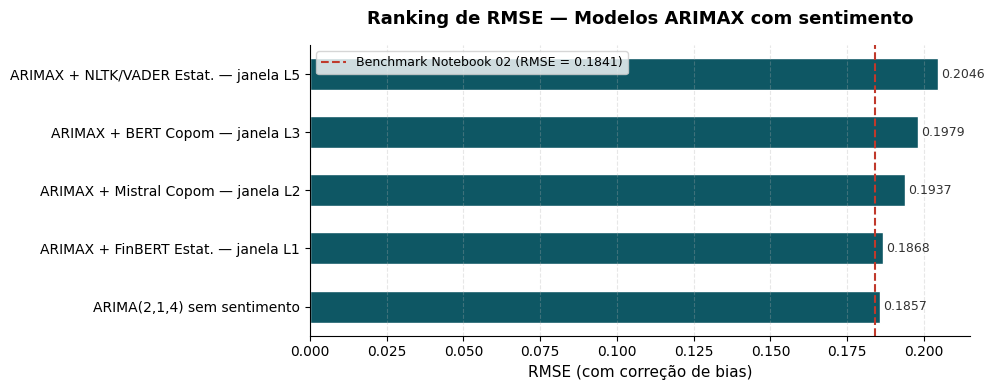

In [ ]:
if not metricas_com_bias.empty:
    # Ordenar para o gráfico de barras (menor RMSE no topo)
    df_grafico = metricas_com_bias.sort_values("RMSE", ascending=True).copy()

    # Nomes curtos para o gráfico
    df_grafico["nome_curto"] = (
        df_grafico["Modelo"]
        .str.replace("Modelo \d+ — ", "", regex=True)
        .str.replace("Modelo C — ", "", regex=True)
    )

    fig, ax = plt.subplots(figsize=(10, max(4, len(df_grafico) * 0.7)))

    barras = ax.barh(
        df_grafico["nome_curto"],
        df_grafico["RMSE"],
        color=COLOR,
        edgecolor="white",
        height=0.55
    )

    # Linha do benchmark
    ax.axvline(
        x=RMSE_BASE_ARIMA_BIAS,
        color="#c0392b",
        linewidth=1.5,
        linestyle="--",
        label=f"Benchmark Notebook 02 (RMSE = {RMSE_BASE_ARIMA_BIAS:.4f})"
    )

    # Rótulos nas barras
    for barra in barras:
        ax.text(
            barra.get_width() + 0.001,
            barra.get_y() + barra.get_height() / 2,
            f"{barra.get_width():.4f}",
            va="center",
            ha="left",
            fontsize=9,
            color="#333333"
        )

    ax.set_xlabel("RMSE (com correção de bias)", fontsize=11)
    ax.set_title(
        "Ranking de RMSE — Modelos ARIMAX com sentimento",
        fontsize=13,
        fontweight="bold",
        pad=15
    )
    ax.legend(fontsize=9)
    ax.grid(axis="x", alpha=0.3, linestyle="--")
    ax.spines[["top", "right"]].set_visible(False)

    plt.tight_layout()
    plt.show()

Embora o Notebook 06 replique a lógica metodológica do Notebook 02 — mesma variável-alvo, mesmo horizonte de previsão h=3, mesmo corte temporal por `data_alvo`, mesma ordem ARIMA(2,1,4), mesma avaliação walk-forward e mesma correção de bias estimada apenas no treino, observou-se pequena diferença entre o RMSE do ARIMA sem sentimento recalculado no Notebook 06 e o benchmark obtido no Notebook 02.

Essa diferença decorre da implementação computacional: no Notebook 02, o modelo ARIMA é estimado diretamente pela classe `ARIMA` do `statsmodels`, enquanto no Notebook 06 o modelo sem sentimento é estimado pela estrutura `SARIMAX`, necessária para permitir a inclusão posterior de variáveis exógenas de sentimento. Como as rotinas de estimação não são numericamente idênticas, especialmente diante de possíveis avisos de convergência, pequenas diferenças nos parâmetros, no bias estimado e nas métricas finais podem ocorrer.

Assim, o resultado do Notebook 06 deve ser interpretado como metodologicamente comparável ao Notebook 02, mas não como uma reprodução numérica exata do benchmark.

### Gráfico 2 — Observado vs Previsto no período de teste

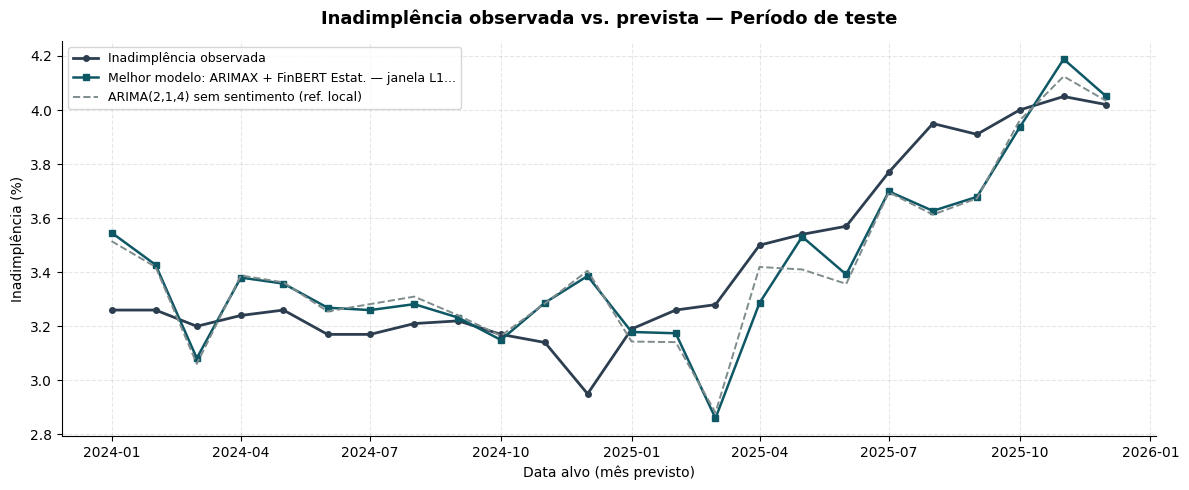

In [ ]:
# Identificar o resultado do melhor modelo com sentimento
resultado_melhor = None
resultado_modelo0 = None

for r in resultados_modelos:
    if r["status"] == "ok":
        if r["nome"] == melhor_modelo_nome:
            resultado_melhor = r
        if "sem sentimento" in r["nome"]:
            resultado_modelo0 = r

if resultado_melhor is not None:
    datas_plot = pd.to_datetime(resultado_melhor["datas_alvo_teste"])
    y_obs      = resultado_melhor["y_obs_teste"]
    y_prev_m   = resultado_melhor["y_pred_teste_corr"]

    fig, ax = plt.subplots(figsize=(12, 5))

    ax.plot(datas_plot, y_obs, color="#2c3e50", linewidth=2,
            label="Inadimplência observada", marker="o", markersize=4)

    ax.plot(datas_plot, y_prev_m, color=COLOR, linewidth=1.8,
            linestyle="-", label=f"Melhor modelo: {melhor_modelo_nome[:40]}...",
            marker="s", markersize=4)

    # Previsão do Modelo 0 (referência local), se disponível
    if resultado_modelo0 is not None:
        datas_m0 = pd.to_datetime(resultado_modelo0["datas_alvo_teste"])
        ax.plot(datas_m0, resultado_modelo0["y_pred_teste_corr"],
                color="#7f8c8d", linewidth=1.4, linestyle="--",
                label="ARIMA(2,1,4) sem sentimento (ref. local)")

    ax.set_title(
        "Inadimplência observada vs. prevista — Período de teste",
        fontsize=13, fontweight="bold", pad=12
    )
    ax.set_xlabel("Data alvo (mês previsto)", fontsize=10)
    ax.set_ylabel("Inadimplência (%)", fontsize=10)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3, linestyle="--")
    ax.spines[["top", "right"]].set_visible(False)

    plt.tight_layout()
    plt.show()
else:
    print("Gráfico não disponível — nenhum modelo com sentimento estimado com sucesso.")

### Gráfico 3 — Comparação visual com o benchmark

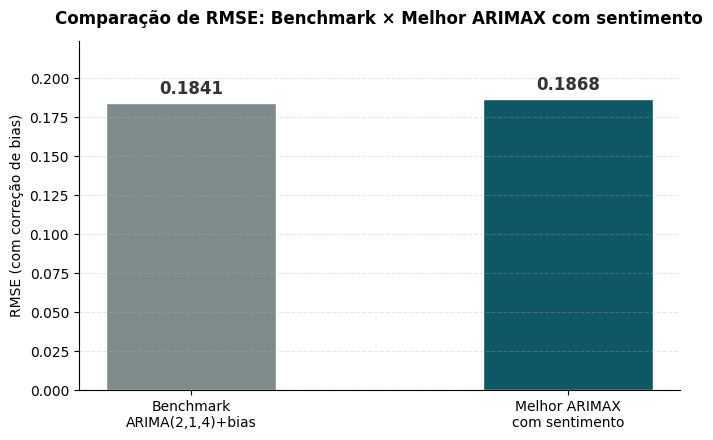

In [ ]:
if melhor_rmse is not None:
    nomes_comp  = ["Benchmark\nARIMA(2,1,4)+bias", "Melhor ARIMAX\ncom sentimento"]
    rmses_comp  = [RMSE_BASE_ARIMA_BIAS, melhor_rmse]
    cores_comp  = ["#7f8c8d", COLOR]

    fig, ax = plt.subplots(figsize=(7, 4.5))

    barras = ax.bar(
        nomes_comp, rmses_comp,
        color=cores_comp,
        width=0.45,
        edgecolor="white"
    )

    for barra, val in zip(barras, rmses_comp):
        ax.text(
            barra.get_x() + barra.get_width() / 2,
            barra.get_height() + 0.003,
            f"{val:.4f}",
            ha="center", va="bottom",
            fontsize=12, fontweight="bold", color="#333333"
        )

    ax.set_ylabel("RMSE (com correção de bias)", fontsize=10)
    ax.set_title(
        "Comparação de RMSE: Benchmark × Melhor ARIMAX com sentimento",
        fontsize=12, fontweight="bold", pad=12
    )
    ax.set_ylim(0, max(rmses_comp) * 1.2)
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", alpha=0.3, linestyle="--")

    plt.tight_layout()
    plt.show()

## Conclusão do exercício comparativo

A comparação entre o modelo benchmark sem sentimento e os modelos ARIMAX com variáveis de sentimento indica que a inclusão das variáveis textuais não gerou ganho preditivo no período de teste analisado.

O benchmark oficial do Notebook 02, representado pelo modelo ARIMA(2,1,4) com correção de bias, apresentou RMSE de **0,1841**, sendo o menor erro entre os modelos comparados. No Notebook 06, o modelo ARIMA(2,1,4) sem sentimento, reestimado localmente pela estrutura SARIMAX, obteve RMSE de **0,1857**, valor muito próximo ao benchmark original. Essa pequena diferença é esperada, pois os dois notebooks utilizam rotinas computacionais distintas para estimar modelos equivalentes.

Entre os modelos com sentimento, o melhor desempenho foi obtido pelo modelo **ARIMAX + FinBERT Estatísticas — janela L1**, com RMSE de **0,1868**. Embora esse resultado tenha ficado muito próximo do ARIMA sem sentimento reestimado no Notebook 06, ele ainda apresentou erro ligeiramente superior tanto em relação ao benchmark oficial do Notebook 02 quanto em relação ao modelo sem sentimento local.

Dessa forma, os resultados sugerem que, para a amostra e a especificação utilizadas, as variáveis de sentimento não melhoraram a capacidade de previsão da inadimplência em relação ao modelo puramente temporal. Em outras palavras, o comportamento passado da inadimplência, capturado pelo ARIMA, continuou sendo suficiente para produzir previsões ligeiramente mais precisas do que os modelos que incorporaram sentimento textual.

A análise gráfica reforça essa conclusão. O modelo ARIMAX com sentimento acompanha razoavelmente bem a trajetória observada da inadimplência, especialmente nos movimentos gerais de queda e alta ao longo do período de teste. No entanto, essa aderência visual não se traduziu em menor erro agregado. O ranking de RMSE mostra que todos os modelos com sentimento ficaram acima da linha de referência do benchmark, indicando ausência de ganho quantitativo em termos de erro preditivo.

Portanto, a principal conclusão do exercício é que o sentimento extraído dos documentos do Banco Central pode conter informação econômica relevante, mas, nesta aplicação específica, não apresentou ganho incremental suficiente para superar o modelo ARIMA sem sentimento. O resultado não invalida o uso de análise de sentimento, mas indica que sua contribuição preditiva foi limitada diante da forte persistência temporal da própria série de inadimplência.

Assim, para fins do trabalho, o modelo ARIMA(2,1,4) com correção de bias permanece como o melhor benchmark preditivo, enquanto os modelos ARIMAX com sentimento devem ser interpretados como uma extensão metodológica relevante, porém sem melhora estatística em termos de RMSE no período avaliado.